Category counts:
category
other          120
overserved      22
underserved      4
Name: count, dtype: int64


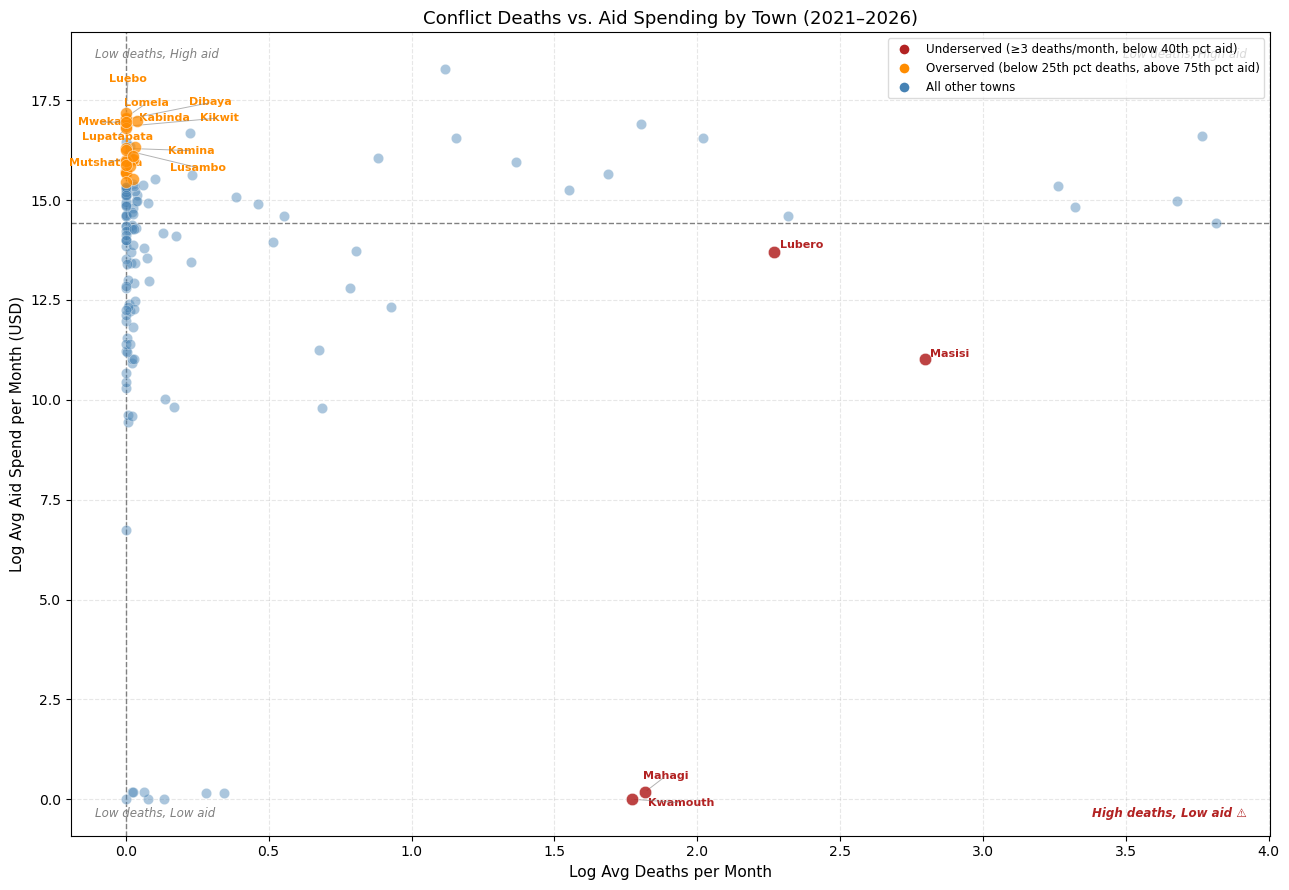

Saved scatter_conflict_aid.png


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text
from matplotlib.lines import Line2D
from linearmodels.panel import PanelOLS
import warnings
warnings.filterwarnings('ignore')

# ── Load panel ─────────────────────────────────────────────────────────────
panel = pd.read_csv('/Users/jackzipper/QSS20/final_project/final_project_data/violence_aid_merged.csv')

# ── Compute per-town averages across all months ────────────────────────────
town_avg = (
    panel
    .groupby('admin2_name')
    .agg(
        avg_deaths = ('total_deaths',    'mean'),
        avg_aid    = ('total_aid_spend', 'mean')
    )
    .reset_index()
)

# ── Log-transform both axes (average first, then log) ─────────────────────
town_avg['log_avg_deaths'] = np.log(town_avg['avg_deaths'] + 1)
town_avg['log_avg_aid']    = np.log(town_avg['avg_aid']    + 1)

# ── Thresholds ─────────────────────────────────────────────────────────────
p40_aid     = town_avg['avg_aid'].quantile(0.40)
p25_deaths  = town_avg['avg_deaths'].quantile(0.25)
p75_aid     = town_avg['avg_aid'].quantile(0.75)

# ── Categorize towns ───────────────────────────────────────────────────────
def categorize(row):
    if row['avg_deaths'] >= 3 and row['avg_aid'] <= p40_aid:
        return 'underserved'
    elif row['avg_deaths'] <= p25_deaths and row['avg_aid'] >= p75_aid:
        return 'overserved'
    else:
        return 'other'

town_avg['category'] = town_avg.apply(categorize, axis=1)

print("Category counts:")
print(town_avg['category'].value_counts())

# ── Underserved score for labeling (only underserved towns) ────────────────
underserved = town_avg[town_avg['category'] == 'underserved'].copy()
underserved['underserved_score'] = (
    underserved['avg_deaths'].rank(pct=True) -
    underserved['avg_aid'].rank(pct=True)
)
top15_underserved = underserved.nlargest(15, 'underserved_score')

# Overserved: label top 10 by aid spend among overserved towns
overserved  = town_avg[town_avg['category'] == 'overserved'].copy()
top10_overserved = overserved.nlargest(10, 'avg_aid')

# ── Color map ──────────────────────────────────────────────────────────────
color_map = {'underserved': 'firebrick', 'overserved': 'darkorange', 'other': 'steelblue'}
town_avg['color'] = town_avg['category'].map(color_map)

# ── Jitter ─────────────────────────────────────────────────────────────────
np.random.seed(42)
jitter_strength_x = town_avg['log_avg_deaths'].std() * 0.05
jitter_strength_y = town_avg['log_avg_aid'].std()     * 0.05

town_avg['x'] = (town_avg['log_avg_deaths'] +
                 np.random.uniform(-jitter_strength_x, jitter_strength_x, len(town_avg))).clip(lower=0)
town_avg['y'] = (town_avg['log_avg_aid']    +
                 np.random.uniform(-jitter_strength_y, jitter_strength_y, len(town_avg))).clip(lower=0)

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 9))

# Plot in order: other → overserved → underserved (so red sits on top)
for cat, zorder, alpha, size in [('other', 3, 0.45, 55),
                                   ('overserved', 4, 0.75, 75),
                                   ('underserved', 5, 0.85, 80)]:
    mask = town_avg['category'] == cat
    ax.scatter(
        town_avg.loc[mask, 'x'],
        town_avg.loc[mask, 'y'],
        c=color_map[cat],
        alpha=alpha,
        edgecolors='white',
        linewidths=0.4,
        s=size,
        zorder=zorder
    )

# Quadrant lines at median
med_x = town_avg['log_avg_deaths'].median()
med_y = town_avg['log_avg_aid'].median()
ax.axvline(med_x, color='gray', linestyle='--', linewidth=1, zorder=2)
ax.axhline(med_y, color='gray', linestyle='--', linewidth=1, zorder=2)

# Quadrant labels
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

ax.text(xmax * 0.98, ymax * 0.98, 'Low deaths, High aid',
        ha='right', va='top',    fontsize=8.5, color='gray', fontstyle='italic')
ax.text(xmax * 0.98, ymin + (ymax - ymin) * 0.02, 'High deaths, Low aid ⚠',
        ha='right', va='bottom', fontsize=8.5, color='firebrick',
        fontstyle='italic', fontweight='bold')
ax.text(xmin + (xmax - xmin) * 0.02, ymax * 0.98, 'Low deaths, High aid',
        ha='left',  va='top',    fontsize=8.5, color='gray', fontstyle='italic')
ax.text(xmin + (xmax - xmin) * 0.02, ymin + (ymax - ymin) * 0.02, 'Low deaths, Low aid',
        ha='left',  va='bottom', fontsize=8.5, color='gray', fontstyle='italic')

# ── Labels via adjustText ──────────────────────────────────────────────────
texts = []

for _, row in top15_underserved.iterrows():
    matched = town_avg[town_avg['admin2_name'] == row['admin2_name']].iloc[0]
    texts.append(ax.text(
        matched['x'], matched['y'],
        row['admin2_name'],
        fontsize=8, color='firebrick', fontweight='bold'
    ))

for _, row in top10_overserved.iterrows():
    matched = town_avg[town_avg['admin2_name'] == row['admin2_name']].iloc[0]
    texts.append(ax.text(
        matched['x'], matched['y'],
        row['admin2_name'],
        fontsize=8, color='darkorange', fontweight='bold'
    ))

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.7, alpha=0.6),
    expand_points=(1.5, 1.5),
    expand_text=(1.5, 1.5),
    force_text=(0.5, 0.5)
)

# ── Formatting ─────────────────────────────────────────────────────────────
ax.set_xlabel('Log Avg Deaths per Month',          fontsize=11)
ax.set_ylabel('Log Avg Aid Spend per Month (USD)', fontsize=11)
ax.set_title(
    'Conflict Deaths vs. Aid Spending by Town (2021–2026)',
    fontsize=13
)
ax.grid(True, linestyle='--', alpha=0.3, zorder=1)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='firebrick',
           markersize=8, label='Underserved (≥3 deaths/month, below 40th pct aid)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='darkorange',
           markersize=8, label='Overserved (below 25th pct deaths, above 75th pct aid)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=8, label='All other towns'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=8.5, framealpha=0.7)

plt.tight_layout()
plt.savefig('/Users/jackzipper/QSS20/final_project/output/scatter_conflict_aid.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved scatter_conflict_aid.png")

In [15]:
n_underserved = (town_avg['category'] == 'underserved').sum()
n_overserved  = (town_avg['category'] == 'overserved').sum()
n_other       = (town_avg['category'] == 'other').sum()
n_total       = len(town_avg)

print(f"Total towns       : {n_total}")
print(f"Underserved towns : {n_underserved} ({n_underserved/n_total*100:.1f}%)")
print(f"Overserved towns  : {n_overserved}  ({n_overserved/n_total*100:.1f}%)")
print(f"Other towns       : {n_other}       ({n_other/n_total*100:.1f}%)")

Total towns       : 146
Underserved towns : 4 (2.7%)
Overserved towns  : 22  (15.1%)
Other towns       : 120       (82.2%)


In [23]:
# ── CELL 4: Prep and fit ───────────────────────────────────────────────────
panel_reg = panel.copy()
panel_reg['year_month']    = pd.to_datetime(panel_reg['year_month'].astype(str))
panel_reg['log_aid_spend'] = np.log(panel_reg['total_aid_spend'] + 1)
panel_reg['log_deaths']    = np.log(panel_reg['total_deaths']    + 1)

panel_reg = panel_reg.sort_values(['admin2_name', 'year_month']).reset_index(drop=True)

panel_reg['log_deaths_lag1'] = panel_reg.groupby('admin2_name')['log_deaths'].shift(1)
panel_reg['log_deaths_lag3'] = panel_reg.groupby('admin2_name')['log_deaths'].shift(3)
panel_reg['log_deaths_lag6'] = panel_reg.groupby('admin2_name')['log_deaths'].shift(6)

panel_reg = panel_reg.set_index(['admin2_name', 'year_month'])

def run_twfe(data, lag_col):
    df  = data[[lag_col, 'log_aid_spend']].dropna()
    res = PanelOLS(
        dependent      = df['log_aid_spend'],
        exog           = df[[lag_col]],
        entity_effects = True,
        time_effects   = True,
    ).fit(cov_type='clustered', cluster_entity=True)
    return res

res_lag1 = run_twfe(panel_reg, 'log_deaths_lag1')
res_lag3 = run_twfe(panel_reg, 'log_deaths_lag3')
res_lag6 = run_twfe(panel_reg, 'log_deaths_lag6')

In [24]:
# ── CELL 5: Save output to .txt ────────────────────────────────────────────
import io, sys

output_path = '/Users/jackzipper/QSS20/final_project/output/violence_aid_regression.txt'

buffer     = io.StringIO()
sys.stdout = buffer

print(f"{'='*60}")
print(f" Summary: Effect of log(deaths) on log(aid spend)")
print(f"{'='*60}")
print(f"{'Lag':<15} {'β':>8} {'SE':>8} {'p-value':>10} {'Sig':>6} {'R²(within)':>12}")
print(f"{'-'*60}")
for res, label, col in [
    (res_lag1, 'Lag 1 month',  'log_deaths_lag1'),
    (res_lag3, 'Lag 3 months', 'log_deaths_lag3'),
    (res_lag6, 'Lag 6 months', 'log_deaths_lag6'),
]:
    p     = res.pvalues[col]
    stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    print(f"  {label:<13} {res.params[col]:>8.4f} {res.std_errors[col]:>8.4f} {p:>10.4f} {stars:>6} {res.rsquared_within:>12.4f}")
print(f"\n*** p<0.01  ** p<0.05  * p<0.1")
print(f"All models include town FE, month FE, and town-clustered standard errors.")

sys.stdout = sys.__stdout__
with open(output_path, 'w') as f:
    f.write(buffer.getvalue())

print(f"Saved regression output → {output_path}")